# rexgen_direct 模型展示教程

## 本 Notebook 解决的问题

如何用**图卷积网络**预测化学反应中哪些键会发生变化，并枚举、排序候选产物？

本教程将 rexgen_direct 的 TensorFlow 1.x 核心模型逐模块翻译为 **PyTorch**，从构件到系统地展示：

```
linearND → WLN消息传递 → 全局注意力 → CoreFinder(Stage 1)
                                    ↓
              差异WLN → CandRanker(Stage 2) → 完整推理流程
```

> **重要说明**: 由于 TF1 checkpoint 无法加载到 PyTorch，所有演示使用**随机初始化权重**。输出数值无实际化学意义，但**架构和数据流完全正确**。论文报告在 USPTO 数据集上 Top-1 准确率约 85.6%。

---

In [1]:
import os, sys, math
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import rdkit.Chem as Chem

torch.manual_seed(42)
np.random.seed(42)

print(f'PyTorch: {torch.__version__}')
print(f'Device: cpu（教学用，无需 GPU）')

PyTorch: 2.10.0+cpu
Device: cpu（教学用，无需 GPU）


## 0. 准备工作：复用 Notebook 2 的数据处理函数

In [2]:
# ====== 从 Notebook 2 复用的数据处理函数 ======

elem_list = ['C', 'N', 'O', 'S', 'F', 'Si', 'P', 'Cl', 'Br', 'Mg', 'Na', 'Ca', 'Fe', 'As', 'Al', 'I', 'B', 'V', 'K',
             'Tl', 'Yb', 'Sb', 'Sn', 'Ag', 'Pd', 'Co', 'Se', 'Ti', 'Zn', 'H', 'Li', 'Ge', 'Cu', 'Au', 'Ni', 'Cd', 'In',
             'Mn', 'Zr', 'Cr', 'Pt', 'Hg', 'Pb', 'W', 'Ru', 'Nb', 'Re', 'Te', 'Rh', 'Tc', 'Ba', 'Bi', 'Hf', 'Mo', 'U',
             'Sm', 'Os', 'Ir', 'Ce', 'Gd', 'Ga', 'Cs', 'unknown']

atom_fdim = len(elem_list) + 6 + 6 + 6 + 1  # 82
bond_fdim = 6
max_nb = 10
binary_fdim = 4 + bond_fdim  # 10
INVALID_BOND = -1

def onek_encoding_unk(x, allowable_set):
    if x not in allowable_set:
        x = allowable_set[-1]
    return list(map(lambda s: x == s, allowable_set))

def atom_features(atom):
    return np.array(
        onek_encoding_unk(atom.GetSymbol(), elem_list)
        + onek_encoding_unk(atom.GetDegree(), [0, 1, 2, 3, 4, 5])
        + onek_encoding_unk(atom.GetExplicitValence(), [1, 2, 3, 4, 5, 6])
        + onek_encoding_unk(atom.GetImplicitValence(), [0, 1, 2, 3, 4, 5])
        + [atom.GetIsAromatic()], dtype=np.float32)

def bond_features(bond):
    bt = bond.GetBondType()
    return np.array([
        bt == Chem.rdchem.BondType.SINGLE, bt == Chem.rdchem.BondType.DOUBLE,
        bt == Chem.rdchem.BondType.TRIPLE, bt == Chem.rdchem.BondType.AROMATIC,
        bond.GetIsConjugated(), bond.IsInRing()], dtype=np.float32)

def smiles2graph(smiles, idxfunc=lambda x: x.GetIdx()):
    mol = Chem.MolFromSmiles(smiles)
    if not mol: raise ValueError(f'Could not parse: {smiles}')
    n_atoms = mol.GetNumAtoms()
    n_bonds = max(mol.GetNumBonds(), 1)
    fatoms = np.zeros((n_atoms, atom_fdim))
    fbonds = np.zeros((n_bonds, bond_fdim))
    atom_nb = np.zeros((n_atoms, max_nb), dtype=np.int32)
    bond_nb = np.zeros((n_atoms, max_nb), dtype=np.int32)
    num_nbs = np.zeros((n_atoms,), dtype=np.int32)
    for atom in mol.GetAtoms():
        idx = idxfunc(atom)
        fatoms[idx] = atom_features(atom)
    for bond in mol.GetBonds():
        a1, a2, idx = idxfunc(bond.GetBeginAtom()), idxfunc(bond.GetEndAtom()), bond.GetIdx()
        atom_nb[a1, num_nbs[a1]], atom_nb[a2, num_nbs[a2]] = a2, a1
        bond_nb[a1, num_nbs[a1]], bond_nb[a2, num_nbs[a2]] = idx, idx
        num_nbs[a1] += 1; num_nbs[a2] += 1
        fbonds[idx] = bond_features(bond)
    return fatoms, fbonds, atom_nb, bond_nb, num_nbs

def pack2D(arr_list):
    N, M = max(x.shape[0] for x in arr_list), max(x.shape[1] for x in arr_list)
    a = np.zeros((len(arr_list), N, M))
    for i, arr in enumerate(arr_list): a[i, :arr.shape[0], :arr.shape[1]] = arr
    return a

def pack2D_withidx(arr_list):
    N, M = max(x.shape[0] for x in arr_list), max(x.shape[1] for x in arr_list)
    a = np.zeros((len(arr_list), N, M, 2))
    for i, arr in enumerate(arr_list):
        a[i, :arr.shape[0], :arr.shape[1], 0] = i
        a[i, :arr.shape[0], :arr.shape[1], 1] = arr
    return a

def pack1D(arr_list):
    N = max(x.shape[0] for x in arr_list)
    a = np.zeros((len(arr_list), N))
    for i, arr in enumerate(arr_list): a[i, :arr.shape[0]] = arr
    return a

def get_mask(arr_list):
    N = max(x.shape[0] for x in arr_list)
    a = np.zeros((len(arr_list), N))
    for i, arr in enumerate(arr_list): a[i, :arr.shape[0]] = 1
    return a

def smiles2graph_list(smiles_list, idxfunc=lambda x: x.GetIdx()):
    res = [smiles2graph(s, idxfunc) for s in smiles_list]
    fatom_list, fbond_list, gatom_list, gbond_list, nb_list = zip(*res)
    return (pack2D(fatom_list), pack2D(fbond_list),
            pack2D_withidx(gatom_list), pack2D_withidx(gbond_list),
            pack1D(nb_list), get_mask(fatom_list))

def get_bin_feature(r, max_natoms):
    comp = {}
    for i, s in enumerate(r.split('.')):
        mol = Chem.MolFromSmiles(s)
        for atom in mol.GetAtoms():
            comp[atom.GetIntProp('molAtomMapNumber') - 1] = i
    n_comp = len(r.split('.'))
    rmol = Chem.MolFromSmiles(r)
    n_atoms = rmol.GetNumAtoms()
    bond_map = {}
    for bond in rmol.GetBonds():
        a1 = bond.GetBeginAtom().GetIntProp('molAtomMapNumber') - 1
        a2 = bond.GetEndAtom().GetIntProp('molAtomMapNumber') - 1
        bond_map[(a1, a2)] = bond_map[(a2, a1)] = bond
    features = []
    for i in range(max_natoms):
        for j in range(max_natoms):
            f = np.zeros((binary_fdim,))
            if i >= n_atoms or j >= n_atoms or i == j:
                features.append(f); continue
            if (i, j) in bond_map:
                f[1:1 + bond_fdim] = bond_features(bond_map[(i, j)])
            else:
                f[0] = 1.0
            f[-4] = 1.0 if comp[i] != comp[j] else 0.0
            f[-3] = 1.0 if comp[i] == comp[j] else 0.0
            f[-2] = 1.0 if n_comp == 1 else 0.0
            f[-1] = 1.0 if n_comp > 1 else 0.0
            features.append(f)
    return np.vstack(features).reshape((max_natoms, max_natoms, binary_fdim))

from functools import partial
smiles2graph_batch = partial(smiles2graph_list, idxfunc=lambda x: x.GetIntProp('molAtomMapNumber') - 1)

print('数据处理函数已加载 ✓')

数据处理函数已加载 ✓


In [3]:
# 准备示例数据
df = pd.read_csv('data/demo_reactions.csv')

# 取第一条反应作为演示
rxn = df.iloc[0]['rxn_smiles']
reactant_smi = rxn.split('>>')[0]
edits_str = df.iloc[0]['edits']

# 为 CoreFinder 准备输入（需要 batch_size=2 的格式，原版设计如此）
batch_size = 2
src_batch = [reactant_smi, reactant_smi]  # 重复两次填充 batch
src_tuple = smiles2graph_batch(src_batch)

rmol = Chem.MolFromSmiles(reactant_smi)
n_atoms = rmol.GetNumAtoms()

# 计算二值特征
bin_feat_np = get_bin_feature(reactant_smi, n_atoms)
bin_feat_batch = np.array([bin_feat_np, bin_feat_np])  # (2, n_atoms, n_atoms, 10)

# 转换为 PyTorch tensor
input_atom = torch.FloatTensor(src_tuple[0])    # (2, n_atoms, atom_fdim)
input_bond = torch.FloatTensor(src_tuple[1])    # (2, n_bonds, bond_fdim)
atom_graph = torch.LongTensor(src_tuple[2].astype(np.int64))  # (2, n_atoms, max_nb, 2)
bond_graph = torch.LongTensor(src_tuple[3].astype(np.int64))  # (2, n_bonds, max_nb, 2)
num_nbs = torch.LongTensor(src_tuple[4].astype(np.int64))     # (2, n_atoms)
node_mask = torch.FloatTensor(src_tuple[5])      # (2, n_atoms)
binary = torch.FloatTensor(bin_feat_batch)        # (2, n_atoms, n_atoms, 10)

print(f'反应: {df.iloc[0]["reaction_name"]}')
print(f'反应物原子数: {n_atoms}')
print(f'输入 tensor 形状:')
print(f'  input_atom: {input_atom.shape}')
print(f'  input_bond: {input_bond.shape}')
print(f'  atom_graph: {atom_graph.shape}')
print(f'  bond_graph: {bond_graph.shape}')
print(f'  num_nbs:    {num_nbs.shape}')
print(f'  node_mask:  {node_mask.shape}')
print(f'  binary:     {binary.shape}')

反应: 亲核取代_Cl被NH2取代
反应物原子数: 16
输入 tensor 形状:
  input_atom: torch.Size([2, 16, 82])
  input_bond: torch.Size([2, 14, 6])
  atom_graph: torch.Size([2, 16, 10, 2])
  bond_graph: torch.Size([2, 16, 10, 2])
  num_nbs:    torch.Size([2, 16])
  node_mask:  torch.Size([2, 16])
  binary:     torch.Size([2, 16, 16, 10])


[15:44:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[15:44:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:44:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[15:44:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:44:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[15:44:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:44:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[15:44:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:44:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[15:44:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.IMPLICIT) instead
[15:44:23] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[15:44:23] DEPRECATIO

## 1. 教学版 vs 原版差异表

### TF1 → PyTorch 核心翻译对照

| TensorFlow 1.x | PyTorch | 说明 |
|-----------------|---------|------|
| `tf.placeholder` | `forward()` 参数 | 输入数据 |
| `tf.variable_scope(reuse=True)` | 共享 `nn.Module` 实例 | 权重共享 |
| `tf.gather_nd(tensor, indices)` | PyTorch 高级索引 | 按索引取值 |
| `tf.sequence_mask` | `torch.arange < lengths` | 序列掩码 |
| `session.run(op, feed_dict)` | `model(inputs)` | 前向传播 |
| `linearND(input, size, scope)` | `self.linear(input)` | 线性变换 |

## 2. LinearND：多维线性层

rexgen_direct 中最基础的组件。`linearND` 对任意维度 tensor 的最后一维做线性变换（等价于 `nn.Linear`，但原版需要手动 reshape）。

> **源码映射**  
> 文件: `rexgen_direct/core_wln_global/nn.py`  
> 函数: `linearND(input_, output_size, scope, reuse, init_bias)`

PyTorch 的 `nn.Linear` 天然支持多维输入，所以翻译非常直接。

In [4]:
# ====== 源码映射 ======
# 文件: rexgen_direct/core_wln_global/nn.py
# 函数: linearND()
# TF1 原版:
#   def linearND(input_, output_size, scope, reuse=False, init_bias=0.0):
#       W = tf.get_variable("Matrix", [shape[-1], output_size])
#       exp_input = tf.reshape(input_, [-1, shape[-1]])
#       res = tf.matmul(exp_input, W) + b
#       res = tf.reshape(res, target_shape)
#
# PyTorch 翻译: nn.Linear 天然支持多维输入，无需手动 reshape

class LinearND(nn.Module):
    """多维线性层，对输入最后一维做线性变换。
    
    等价于 nn.Linear，但命名与原版保持一致。
    当 init_bias=None 时不使用偏置。
    """
    def __init__(self, in_features, out_features, bias=True):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        # 使用与原版相同的初始化方式
        stddev = min(1.0 / math.sqrt(in_features), 0.1)
        nn.init.normal_(self.linear.weight, std=stddev)
        if bias:
            nn.init.zeros_(self.linear.bias)
    
    def forward(self, x):
        return self.linear(x)

# 验证
layer = LinearND(82, 300, bias=False)
x = torch.randn(2, 16, 82)  # (batch, n_atoms, atom_fdim)
y = layer(x)
print(f'LinearND 验证:')
print(f'  输入: {x.shape}')
print(f'  输出: {y.shape}')
print(f'  参数量: {sum(p.numel() for p in layer.parameters())} = {82} × {300}')

LinearND 验证:
  输入: torch.Size([2, 16, 82])
  输出: torch.Size([2, 16, 300])
  参数量: 24600 = 82 × 300


## 3. WLN 消息传递（Weisfeiler-Lehman Network）

WLN 是 rexgen_direct 的核心图卷积模块，通过多轮消息传递更新原子嵌入。

> **源码映射**  
> 文件: `rexgen_direct/core_wln_global/models.py`  
> 函数: `rcnn_wl_last(graph_inputs, batch_size, hidden_size, depth)`

### 消息传递公式

**初始嵌入：**
$$h_i^{(0)} = \text{ReLU}(W_{\text{embed}} \cdot x_i)$$

**每层更新** ($t = 1, \ldots, D$)：

1. **消息计算**（邻居原子嵌入 × 键嵌入）：
$$m_{ij} = (W_{\text{nei}} h_j^{(t-1)}) \odot (W_{\text{bond}} e_{ij})$$

2. **邻居聚合**：
$$f_i^{\text{nei}} = \sum_{j \in N(i)} m_{ij}$$

3. **输出层**（self × neighbors）：
$$\text{output}_i^{(t)} = (W_{\text{self}} h_i^{(t-1)}) \odot f_i^{\text{nei}}$$

4. **标签更新**（拼接后线性变换）：
$$h_i^{(t)} = \text{ReLU}(W_{\text{update}} [h_i^{(t-1)} \| \tilde{f}_i^{\text{nei}}])$$

其中 $\tilde{f}_i^{\text{nei}} = \sum_{j \in N(i)} \text{ReLU}(W_{\text{U2}} [h_j^{(t-1)} \| e_{ij}])$

> **关键设计**: 输出使用 `f_self * f_nei`（元素乘），这区别于标准 GCN 的加法聚合。最终原子嵌入取最后一层的输出（不是所有层拼接）。

In [5]:
# ====== 源码映射 ======
# 文件: rexgen_direct/core_wln_global/models.py
# 函数: rcnn_wl_last()
# TF1 关键代码:
#   fatom_nei = tf.gather_nd(atom_features, atom_graph)
#   fbond_nei = tf.gather_nd(input_bond, bond_graph)
#   h_nei = linearND(fatom_nei, hidden_size, "nei_atom") * linearND(fbond_nei, hidden_size, "nei_bond")
#   mask_nei = tf.sequence_mask(num_nbs, max_nb)
#   f_nei = tf.reduce_sum(h_nei * mask_nei, -2)
#
# PyTorch 翻译:
#   gather_nd → 高级索引 tensor[batch_idx, atom_idx]
#   sequence_mask → torch.arange(max_nb) < num_nbs.unsqueeze(-1)
#   variable_scope(reuse=True) → 同一个 nn.Module 实例

class WLN(nn.Module):
    """Weisfeiler-Lehman Network 消息传递模块。
    
    对应原版 rcnn_wl_last()，权重在各层间共享（reuse=True）。
    """
    def __init__(self, atom_fdim, bond_fdim, hidden_size, depth):
        super().__init__()
        self.hidden_size = hidden_size
        self.depth = depth
        
        # 原子初始嵌入
        self.W_embed = LinearND(atom_fdim, hidden_size, bias=False)
        
        # 消息传递层（权重共享，对应 variable_scope(reuse=True)）
        self.W_nei_atom = LinearND(hidden_size, hidden_size, bias=False)
        self.W_nei_bond = LinearND(bond_fdim, hidden_size, bias=False)
        self.W_self = LinearND(hidden_size, hidden_size, bias=False)
        
        # 标签更新层（也是权重共享）
        self.W_label_U2 = LinearND(hidden_size + bond_fdim, hidden_size)
        self.W_label_U1 = LinearND(hidden_size * 2, hidden_size)
    
    def forward(self, input_atom, input_bond, atom_graph, bond_graph, num_nbs, node_mask):
        """前向传播。
        
        参数:
            input_atom: (batch, n_atoms, atom_fdim)
            input_bond: (batch, n_bonds, bond_fdim)
            atom_graph: (batch, n_atoms, max_nb, 2)  [batch_idx, atom_idx]
            bond_graph: (batch, n_atoms, max_nb, 2)  [batch_idx, bond_idx]
            num_nbs:    (batch, n_atoms)
            node_mask:  (batch, n_atoms, 1)
        
        返回:
            kernels: (batch, n_atoms, hidden_size)  最终原子嵌入
            fp:      (batch, hidden_size)  分子指纹（原子嵌入求和）
        """
        batch_size = input_atom.shape[0]
        
        # 初始嵌入
        atom_features = F.relu(self.W_embed(input_atom))
        
        for t in range(self.depth):
            # ---- gather 邻居特征 ----
            # atom_graph[:,:,:,0] = batch index, atom_graph[:,:,:,1] = neighbor atom index
            batch_idx = atom_graph[:, :, :, 0]  # (batch, n_atoms, max_nb)
            atom_idx = atom_graph[:, :, :, 1]   # (batch, n_atoms, max_nb)
            bond_batch_idx = bond_graph[:, :, :, 0]
            bond_idx = bond_graph[:, :, :, 1]
            
            # 对应 TF 的 gather_nd
            fatom_nei = atom_features[batch_idx, atom_idx]  # (batch, n_atoms, max_nb, hidden_size)
            fbond_nei = input_bond[bond_batch_idx, bond_idx]  # (batch, n_atoms, max_nb, bond_fdim)
            
            # ---- 消息计算 ----
            h_nei_atom = self.W_nei_atom(fatom_nei)   # (batch, n_atoms, max_nb, hidden)
            h_nei_bond = self.W_nei_bond(fbond_nei)   # (batch, n_atoms, max_nb, hidden)
            h_nei = h_nei_atom * h_nei_bond           # 元素乘
            
            # ---- 邻居掩码 ----
            # 对应 tf.sequence_mask
            mask_nei = (torch.arange(max_nb).unsqueeze(0).unsqueeze(0) < 
                       num_nbs.unsqueeze(-1))  # (batch, n_atoms, max_nb)
            mask_nei = mask_nei.unsqueeze(-1).float()  # (batch, n_atoms, max_nb, 1)
            
            # ---- 邻居聚合 ----
            f_nei = (h_nei * mask_nei).sum(dim=2)  # (batch, n_atoms, hidden)
            f_self = self.W_self(atom_features)     # (batch, n_atoms, hidden)
            output = f_nei * f_self * node_mask      # 元素乘 + 节点掩码
            
            # ---- 标签更新 ----
            l_nei = torch.cat([fatom_nei, fbond_nei], dim=-1)  # (batch, n_atoms, max_nb, hidden+bond_fdim)
            nei_label = F.relu(self.W_label_U2(l_nei))
            nei_label = (nei_label * mask_nei).sum(dim=2)  # 聚合
            new_label = torch.cat([atom_features, nei_label], dim=-1)
            atom_features = F.relu(self.W_label_U1(new_label))
        
        kernels = output  # 最后一层的输出
        fp = kernels.sum(dim=1)  # 分子指纹
        return kernels, fp

print('WLN 模块定义完成 ✓')

WLN 模块定义完成 ✓


In [6]:
# 验证 WLN 模块
hidden_size = 300
depth = 3

wln = WLN(atom_fdim, bond_fdim, hidden_size, depth)

mask = node_mask.unsqueeze(-1)  # (batch, n_atoms, 1)
kernels, fp = wln(input_atom, input_bond, atom_graph, bond_graph, num_nbs, mask)

print('WLN 输出验证:')
print(f'  原子嵌入 (kernels): {kernels.shape}  (batch={batch_size}, n_atoms={n_atoms}, hidden={hidden_size})')
print(f'  分子指纹 (fp):      {fp.shape}  (batch={batch_size}, hidden={hidden_size})')
print(f'\nWLN 参数统计:')
total_params = 0
for name, param in wln.named_parameters():
    print(f'  {name:30s} {str(list(param.shape)):20s} ({param.numel():,d})')
    total_params += param.numel()
print(f'  {"总参数量":30s} {total_params:,d}')

WLN 输出验证:
  原子嵌入 (kernels): torch.Size([2, 16, 300])  (batch=2, n_atoms=16, hidden=300)
  分子指纹 (fp):      torch.Size([2, 300])  (batch=2, hidden=300)

WLN 参数统计:
  W_embed.linear.weight          [300, 82]            (24,600)
  W_nei_atom.linear.weight       [300, 300]           (90,000)
  W_nei_bond.linear.weight       [300, 6]             (1,800)
  W_self.linear.weight           [300, 300]           (90,000)
  W_label_U2.linear.weight       [300, 306]           (91,800)
  W_label_U2.linear.bias         [300]                (300)
  W_label_U1.linear.weight       [300, 600]           (180,000)
  W_label_U1.linear.bias         [300]                (300)
  总参数量                           478,800


## 4. 全局注意力机制

WLN 产生的原子嵌入只包含局部信息（$D$ 跳邻域）。全局注意力让每个原子关注分子中所有其他原子，捕捉长程依赖。

> **源码映射**  
> 文件: `rexgen_direct/core_wln_global/directcorefinder.py` 第59-84行  
> 以及: `rexgen_direct/core_wln_global/nntrain_direct.py` 第82-101行

### 注意力公式

1. **原子对特征**：$p_{ij} = h_i + h_j$

2. **注意力分数**（结合二值关系特征）：
$$\alpha_{ij} = \sigma(W_3 \cdot \text{ReLU}(W_1 p_{ij} + W_2 b_{ij}))$$

3. **上下文向量**：
$$c_i = \sum_j \alpha_{ij} h_j$$

其中 $b_{ij}$ 是二值关系特征（10维），$\sigma$ 是 sigmoid 函数。

In [7]:
# ====== 源码映射 ======
# 文件: rexgen_direct/core_wln_global/directcorefinder.py 第59-70行
# TF1 原版:
#   atom_hiddens1 = tf.reshape(atom_hiddens, [batch_size, 1, -1, hidden_size])
#   atom_hiddens2 = tf.reshape(atom_hiddens, [batch_size, -1, 1, hidden_size])
#   atom_pair = atom_hiddens1 + atom_hiddens2
#   att_hidden = tf.nn.relu(linearND(atom_pair, hidden_size) + linearND(binary, hidden_size))
#   att_score = tf.nn.sigmoid(linearND(att_hidden, 1))
#   att_context = att_score * atom_hiddens1
#   att_context = tf.reduce_sum(att_context, 2)

class GlobalAttention(nn.Module):
    """全局注意力模块。
    
    为每对原子 (i,j) 计算注意力分数，生成上下文增强的原子表示。
    """
    def __init__(self, hidden_size, binary_fdim):
        super().__init__()
        self.W_atom_pair = LinearND(hidden_size, hidden_size, bias=False)   # W1
        self.W_bin_feat = LinearND(binary_fdim, hidden_size)                 # W2
        self.W_att_score = LinearND(hidden_size, 1)                          # W3
    
    def forward(self, atom_hiddens, binary_feat):
        """计算全局注意力。
        
        参数:
            atom_hiddens: (batch, n_atoms, hidden_size)
            binary_feat:  (batch, n_atoms, n_atoms, binary_fdim)
        
        返回:
            att_context: (batch, n_atoms, hidden_size)  上下文向量
            att_score:   (batch, n_atoms, n_atoms, 1)  注意力分数
        """
        # 构建原子对特征：h_i + h_j
        h1 = atom_hiddens.unsqueeze(2)  # (batch, n_atoms, 1, hidden)
        h2 = atom_hiddens.unsqueeze(1)  # (batch, 1, n_atoms, hidden)
        atom_pair = h1 + h2              # (batch, n_atoms, n_atoms, hidden)
        
        # 注意力分数
        att_hidden = F.relu(
            self.W_atom_pair(atom_pair) + self.W_bin_feat(binary_feat)
        )
        att_score = torch.sigmoid(self.W_att_score(att_hidden))  # (batch, n_atoms, n_atoms, 1)
        
        # 上下文向量
        att_context = (att_score * h1).sum(dim=2)  # (batch, n_atoms, hidden)
        
        return att_context, att_score

# 验证
attn = GlobalAttention(hidden_size, binary_fdim)
att_context, att_score = attn(kernels, binary)

print('全局注意力输出:')
print(f'  上下文向量: {att_context.shape}  (batch, n_atoms, hidden)')
print(f'  注意力分数: {att_score.shape}  (batch, n_atoms, n_atoms, 1)')
print(f'  注意力值范围: [{att_score.min().item():.4f}, {att_score.max().item():.4f}]')

全局注意力输出:
  上下文向量: torch.Size([2, 16, 300])  (batch, n_atoms, hidden)
  注意力分数: torch.Size([2, 16, 16, 1])  (batch, n_atoms, n_atoms, 1)
  注意力值范围: [0.4392, 0.5068]


/tmp/ipykernel_638397/4723508.py:12: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638397/4723508.py:12: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638397/4723508.py:12: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638397/4723508.py:12: UserWarning: Glyph 34987 (\N{CJK UNIFIED IDEOGRAPH-88AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638397/4723508.py:12: UserWarning: Glyph 20851 (\N{CJK UNIFIED IDEOGRAPH-5173}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638397/4723508.py:12: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_638397/4723508.py:12: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) miss

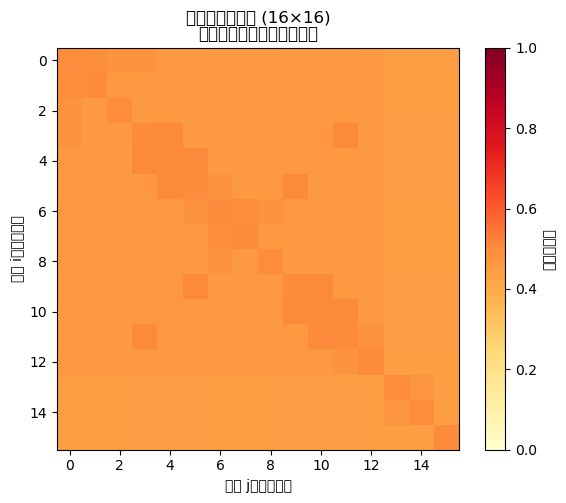

In [8]:
# 可视化注意力矩阵（随机权重，仅展示格式）
import matplotlib.pyplot as plt

att_matrix = att_score[0, :n_atoms, :n_atoms, 0].detach().numpy()

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
im = ax.imshow(att_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xlabel('原子 j（被关注）')
ax.set_ylabel('原子 i（关注者）')
ax.set_title(f'全局注意力矩阵 ({n_atoms}×{n_atoms})\n（随机权重，仅展示格式）')
plt.colorbar(im, ax=ax, label='注意力分数')
plt.tight_layout()
plt.show()

## 5. 完整 CoreFinder（Stage 1）

将 WLN + 全局注意力 + 最终评分层组合成完整的 CoreFinder 模型。

> **源码映射**  
> 文件: `rexgen_direct/core_wln_global/directcorefinder.py`  
> 类: `DirectCoreFinder`

### CoreFinder 完整流程

```
输入 → WLN(3层) → 原子嵌入 h_i
              ↓
    全局注意力 → 上下文 c_i
              ↓
    pair_hidden = W_atom(h_i + h_j) + W_bin(b_ij) + W_ctx(c_i + c_j)
              ↓
    score = W_score(ReLU(pair_hidden))  → (batch, n_atoms×n_atoms×5)
              ↓
    Top-K 键变化预测
```

In [9]:
# ====== 源码映射 ======
# 文件: rexgen_direct/core_wln_global/directcorefinder.py
# 类: DirectCoreFinder + nntrain_direct.py 第82-111行

class CoreFinder(nn.Module):
    """Stage 1: 反应中心预测模型。
    
    预测每对原子之间5种键序变化的得分。
    """
    def __init__(self, atom_fdim, bond_fdim, binary_fdim, hidden_size, depth):
        super().__init__()
        self.hidden_size = hidden_size
        
        # WLN 编码器
        self.wln = WLN(atom_fdim, bond_fdim, hidden_size, depth)
        
        # 全局注意力
        self.attention = GlobalAttention(hidden_size, binary_fdim)
        
        # 最终评分层
        self.W_atom_feat = LinearND(hidden_size, hidden_size, bias=False)   # 原子对特征
        self.W_bin_feat = LinearND(binary_fdim, hidden_size, bias=False)    # 二值特征
        self.W_ctx_feat = LinearND(hidden_size, hidden_size)                # 上下文特征
        self.W_scores = LinearND(hidden_size, 5)                            # 5类键序
    
    def forward(self, input_atom, input_bond, atom_graph, bond_graph, 
                num_nbs, node_mask, binary_feat):
        batch_size = input_atom.shape[0]
        mask = node_mask.unsqueeze(-1)  # (batch, n_atoms, 1)
        
        # Step 1: WLN 编码
        atom_hiddens, _ = self.wln(input_atom, input_bond, atom_graph, 
                                    bond_graph, num_nbs, mask)
        
        # Step 2: 全局注意力
        att_context, att_score = self.attention(atom_hiddens, binary_feat)
        
        # Step 3: 最终评分
        # 原子对特征
        h1 = atom_hiddens.unsqueeze(2)  # (batch, n_atoms, 1, hidden)
        h2 = atom_hiddens.unsqueeze(1)  # (batch, 1, n_atoms, hidden)
        atom_pair = h1 + h2
        
        # 上下文对特征
        c1 = att_context.unsqueeze(2)
        c2 = att_context.unsqueeze(1)
        att_pair = c1 + c2
        
        # 融合评分
        pair_hidden = (self.W_atom_feat(atom_pair) + 
                      self.W_bin_feat(binary_feat) + 
                      self.W_ctx_feat(att_pair))
        pair_hidden = F.relu(pair_hidden)
        pair_hidden = pair_hidden.reshape(batch_size, -1, self.hidden_size)
        
        score = self.W_scores(pair_hidden)  # (batch, n_atoms*n_atoms, 5)
        score = score.reshape(batch_size, -1)  # (batch, n_atoms*n_atoms*5)
        
        return score, att_score

print('CoreFinder 定义完成 ✓')

CoreFinder 定义完成 ✓


In [10]:
# 验证 CoreFinder
core_finder = CoreFinder(atom_fdim, bond_fdim, binary_fdim, hidden_size=300, depth=3)

with torch.no_grad():
    score, att_score = core_finder(input_atom, input_bond, atom_graph, bond_graph,
                                    num_nbs, node_mask, binary)

print('CoreFinder 输出:')
print(f'  score 形状: {score.shape}  (batch, n_atoms×n_atoms×5 = {n_atoms}×{n_atoms}×5 = {n_atoms*n_atoms*5})')
print(f'  att_score 形状: {att_score.shape}')

# Top-K 预测
NK = 10  # 取前10个预测
nbos = 5
topk_scores, topk_indices = torch.topk(score[0], NK)

print(f'\nTop-{NK} 键变化预测（随机权重，无化学意义）:')
print(f'{"排名":>4} {"原子i":>5} {"原子j":>5} {"键序":>6} {"得分":>8}')
print('-' * 35)
bo_names = {0: '0.0(断)', 1: '1.0(单)', 2: '2.0(双)', 3: '3.0(三)', 4: '1.5(芳)'}
for rank, (k_idx, k_score) in enumerate(zip(topk_indices, topk_scores)):
    k = k_idx.item()
    bo_idx = k % nbos
    remaining = k // nbos
    j = remaining % n_atoms
    i = remaining // n_atoms
    print(f'{rank+1:4d} {i+1:5d} {j+1:5d} {bo_names[bo_idx]:>6} {k_score.item():8.4f}')

# 参数量统计
total_params = sum(p.numel() for p in core_finder.parameters())
print(f'\nCoreFinder 总参数量: {total_params:,d} ({total_params/1000:.1f}K)')

CoreFinder 输出:
  score 形状: torch.Size([2, 1280])  (batch, n_atoms×n_atoms×5 = 16×16×5 = 1280)
  att_score 形状: torch.Size([2, 16, 16, 1])

Top-10 键变化预测（随机权重，无化学意义）:
  排名   原子i   原子j     键序       得分
-----------------------------------
   1     5     4 1.0(单)   0.3493
   2     4     5 1.0(单)   0.3493
   3    11    10 1.0(单)   0.3482
   4    10    11 1.0(单)   0.3482
   5     4    12 1.0(单)   0.3326
   6    12     4 1.0(单)   0.3326
   7    12    11 1.0(单)   0.3317
   8    11    12 1.0(单)   0.3317
   9     6     5 1.0(单)   0.3312
  10     5     6 1.0(单)   0.3312

CoreFinder 总参数量: 757,206 (757.2K)


## 6. 差异 WLN（Difference WLN）

Stage 2 的核心模块。对候选产物与反应物的**差异表示**进行进一步编码。

> **源码映射**  
> 文件: `rexgen_direct/rank_diff_wln/models.py`  
> 函数: `wl_diff_net(graph_inputs, atom_features, hidden_size, depth)`

### 差异 WLN 与标准 WLN 的区别

| 方面 | 标准 WLN (Stage 1) | 差异 WLN (Stage 2) |
|------|-------------------|--------------------|
| 初始特征 | 原子特征 → ReLU(W_embed x) | **差异特征**（候选 - 反应物） |
| 输出层 | f_self * f_nei | 无（只做标签更新） |
| 汇聚 | 取最后一层 output | 对最后一层 atom_features 求和 |
| 深度 | 3 | 1 |

In [11]:
# ====== 源码映射 ======
# 文件: rexgen_direct/rank_diff_wln/models.py
# 函数: wl_diff_net() 和 rcnn_wl_only()

class WLNEncoder(nn.Module):
    """Stage 2 用的 WLN 编码器（rcnn_wl_only）。
    
    与 Stage 1 的 WLN 类似，但只有标签更新路径（无 output 层）。
    """
    def __init__(self, atom_fdim, bond_fdim, hidden_size, depth):
        super().__init__()
        self.depth = depth
        self.W_embed = LinearND(atom_fdim, hidden_size, bias=False)
        self.W_label_U2 = LinearND(hidden_size + bond_fdim, hidden_size)
        self.W_label_U1 = LinearND(hidden_size * 2, hidden_size)
    
    def forward(self, input_atom, input_bond, atom_graph, bond_graph, num_nbs):
        atom_features = F.relu(self.W_embed(input_atom))
        
        for t in range(self.depth):
            batch_idx = atom_graph[:, :, :, 0]
            atom_idx = atom_graph[:, :, :, 1]
            bond_batch_idx = bond_graph[:, :, :, 0]
            bond_idx = bond_graph[:, :, :, 1]
            
            fatom_nei = atom_features[batch_idx, atom_idx]
            fbond_nei = input_bond[bond_batch_idx, bond_idx]
            
            mask_nei = (torch.arange(max_nb).unsqueeze(0).unsqueeze(0) < 
                       num_nbs.unsqueeze(-1)).unsqueeze(-1).float()
            
            l_nei = torch.cat([fatom_nei, fbond_nei], dim=-1)
            nei_label = F.relu(self.W_label_U2(l_nei))
            nei_label = (nei_label * mask_nei).sum(dim=2)
            new_label = torch.cat([atom_features, nei_label], dim=-1)
            atom_features = F.relu(self.W_label_U1(new_label))
        
        return atom_features


class DiffWLN(nn.Module):
    """差异 WLN。
    
    在差异特征上做消息传递，输出反应指纹。
    """
    def __init__(self, hidden_size, bond_fdim, depth=1):
        super().__init__()
        self.depth = depth
        self.W_label_U2 = LinearND(hidden_size + bond_fdim, hidden_size)
        self.W_label_U1 = LinearND(hidden_size * 2, hidden_size)
    
    def forward(self, input_bond, atom_graph, bond_graph, num_nbs, atom_features):
        """对差异特征做消息传递。
        
        atom_features: 已经是差异特征（候选 - 反应物）
        返回: 反应指纹 (n_candidates, hidden_size)
        """
        for t in range(self.depth):
            batch_idx = atom_graph[:, :, :, 0]
            atom_idx = atom_graph[:, :, :, 1]
            bond_batch_idx = bond_graph[:, :, :, 0]
            bond_idx = bond_graph[:, :, :, 1]
            
            fatom_nei = atom_features[batch_idx, atom_idx]
            fbond_nei = input_bond[bond_batch_idx, bond_idx]
            
            mask_nei = (torch.arange(max_nb).unsqueeze(0).unsqueeze(0) < 
                       num_nbs.unsqueeze(-1)).unsqueeze(-1).float()
            
            l_nei = torch.cat([fatom_nei, fbond_nei], dim=-1)
            nei_label = F.relu(self.W_label_U2(l_nei))
            nei_label = (nei_label * mask_nei).sum(dim=2)
            new_label = torch.cat([atom_features, nei_label], dim=-1)
            atom_features = F.relu(self.W_label_U1(new_label))
        
        # 对原子维度求和得到反应指纹
        return atom_features.sum(dim=1)  # (n_molecules, hidden_size)

print('DiffWLN 定义完成 ✓')

DiffWLN 定义完成 ✓


## 7. 完整 CandRanker（Stage 2）

> **源码映射**  
> 文件: `rexgen_direct/rank_diff_wln/directcandranker.py`  
> 类: `DirectCandRanker`

### CandRanker 完整流程

```
[反应物图, 候选1图, 候选2图, ...] → WLN编码器 → 所有分子的原子嵌入
                                                    ↓
                               差异 = 候选嵌入 - 反应物嵌入
                                                    ↓
                               拼接 [反应物嵌入; 差异1; 差异2; ...]
                                                    ↓
                               差异 WLN(1层) → 反应指纹
                                                    ↓
                               线性评分 + CoreFinder偏置 → 候选排序
```

In [12]:
# ====== 源码映射 ======
# 文件: rexgen_direct/rank_diff_wln/directcandranker.py
# 类: DirectCandRanker

# Stage 2 使用不同的特征维度
atom_fdim_s2 = len(elem_list) + 7 + 6 + 6 + 6 + 1  # 89
bond_fdim_s2 = 5

class CandRanker(nn.Module):
    """Stage 2: 候选产物排序模型。
    
    将反应物和所有候选产物一起编码，计算差异表示，
    然后对候选产物评分排序。
    """
    def __init__(self, atom_fdim, bond_fdim, hidden_size, depth=3, diff_depth=1):
        super().__init__()
        self.hidden_size = hidden_size
        
        # 分子编码器
        self.mol_encoder = WLNEncoder(atom_fdim, bond_fdim, hidden_size, depth)
        
        # 差异编码器
        self.diff_encoder = DiffWLN(hidden_size, bond_fdim, diff_depth)
        
        # 评分层
        self.W_hidden = nn.Linear(hidden_size, hidden_size)
        self.W_score = nn.Linear(hidden_size, 1)
    
    def forward(self, input_atom, input_bond, atom_graph, bond_graph, 
                num_nbs, core_bias):
        """前向传播。
        
        输入中第一个分子是反应物，其余是候选产物。
        """
        # Step 1: 编码所有分子
        fp_all = self.mol_encoder(input_atom, input_bond, atom_graph, 
                                   bond_graph, num_nbs)
        
        # Step 2: 计算差异
        reactant = fp_all[0:1]           # (1, n_atoms, hidden)
        candidates = fp_all[1:]           # (n_cand, n_atoms, hidden)
        diff = candidates - reactant      # 候选 - 反应物
        diff_with_reactant = torch.cat([reactant, diff], dim=0)  # 包含反应物
        
        # Step 3: 差异 WLN
        reaction_fp = self.diff_encoder(input_bond, atom_graph, bond_graph,
                                         num_nbs, diff_with_reactant)
        reaction_fp = reaction_fp[1:]  # 去掉反应物自身
        
        # Step 4: 评分
        reaction_fp = F.relu(self.W_hidden(reaction_fp))
        score = self.W_score(reaction_fp).squeeze(-1) + core_bias
        prob = F.softmax(score, dim=0)
        
        return score, prob

# 参数量统计
cand_ranker = CandRanker(atom_fdim_s2, bond_fdim_s2, hidden_size=500, depth=3, diff_depth=1)
total_params = sum(p.numel() for p in cand_ranker.parameters())

print('CandRanker 参数统计:')
print(f'  总参数量: {total_params:,d} ({total_params/1000:.1f}K)')
print(f'\n模块分解:')
for name, module in cand_ranker.named_children():
    n_params = sum(p.numel() for p in module.parameters())
    print(f'  {name:20s} {n_params:>10,d} 参数')

CandRanker 参数统计:
  总参数量: 1,802,501 (1802.5K)

模块分解:
  mol_encoder             798,000 参数
  diff_encoder            753,500 参数
  W_hidden                250,500 参数
  W_score                     501 参数


## 8. 两阶段完整推理流程

现在将所有组件组合在一起，演示从反应物 SMILES 到产物预测的完整流程。

> **再次提醒**: 使用随机权重，输出无化学意义。

In [13]:
# ====== 完整推理流程 ======

BOND_TYPE_MAP = {
    0: None,
    1: Chem.rdchem.BondType.SINGLE,
    2: Chem.rdchem.BondType.DOUBLE,
    3: Chem.rdchem.BondType.TRIPLE,
    4: Chem.rdchem.BondType.AROMATIC,
}
bond_types_as_double = {0.0: 0, 1.0: 1, 2.0: 2, 3.0: 3, 1.5: 4}

def edit_mol_simple(rmol, edits):
    """应用键编辑生成产物。"""
    new_mol = Chem.RWMol(rmol)
    amap = {}
    for atom in rmol.GetAtoms():
        amap[atom.GetIntProp('molAtomMapNumber')] = atom.GetIdx()
    for x, y, t in edits:
        bond = new_mol.GetBondBetweenAtoms(amap[x], amap[y])
        if bond is not None:
            new_mol.RemoveBond(amap[x], amap[y])
        if t > 0:
            new_mol.AddBond(amap[x], amap[y], BOND_TYPE_MAP[t])
    pred_mol = new_mol.GetMol()
    for atom in pred_mol.GetAtoms():
        atom.ClearProp('molAtomMapNumber')
    return Chem.MolToSmiles(pred_mol)

# ---- Stage 1: 反应中心预测 ----
print('=' * 60)
print('Stage 1: CoreFinder 反应中心预测')
print('=' * 60)

rxn = df.iloc[0]['rxn_smiles']
reactant_smi = rxn.split('>>')[0]

core_finder = CoreFinder(atom_fdim, bond_fdim, binary_fdim, hidden_size=300, depth=3)

with torch.no_grad():
    score, att = core_finder(input_atom, input_bond, atom_graph, bond_graph,
                              num_nbs, node_mask, binary)

# 解码 Top-K 预测
NK = 20
bindex_to_o = {0: 0.0, 1: 1.0, 2: 2.0, 3: 3.0, 4: 1.5}
topk_scores, topk_indices = torch.topk(score[0], NK)

bond_preds = []
bond_scores = []
cur_dim = n_atoms

for j in range(NK):
    k = topk_indices[j].item()
    bindex = k % nbos
    remaining = k // nbos
    y = remaining % cur_dim + 1
    x = remaining // cur_dim + 1
    if x < y:  # 保持规范顺序
        bo = bindex_to_o[bindex]
        bond_preds.append(f'{x}-{y}-{bo}')
        bond_scores.append(topk_scores[j].item())

print(f'\n反应: {df.iloc[0]["reaction_name"]}')
print(f'反应物原子数: {n_atoms}')
print(f'\nTop 键变化预测（随机权重）:')
for i, (pred, sc) in enumerate(zip(bond_preds[:8], bond_scores[:8])):
    print(f'  {i+1}. {pred}  (score: {sc:.4f})')

Stage 1: CoreFinder 反应中心预测

反应: 亲核取代_Cl被NH2取代
反应物原子数: 16

Top 键变化预测（随机权重）:
  1. 4-6-1.5  (score: 0.5308)
  2. 4-11-1.5  (score: 0.4635)
  3. 4-10-1.5  (score: 0.4560)
  4. 4-6-3.0  (score: 0.4486)
  5. 4-5-1.5  (score: 0.4358)
  6. 6-11-1.5  (score: 0.4340)
  7. 6-12-1.5  (score: 0.4176)
  8. 4-12-1.5  (score: 0.4069)


In [14]:
# ---- 候选枚举（使用真实编辑模拟） ----
print('=' * 60)
print('候选枚举')
print('=' * 60)

# 在实际推理中，用 Stage 1 的 Top-K 预测进行组合枚举。
# 这里为简化演示，直接用真实编辑 + 几个干扰候选。
true_edits = df.iloc[0]['edits']
print(f'真实编辑: {true_edits}')

# 模拟候选列表
rmol = Chem.MolFromSmiles(reactant_smi)

candidate_edits_list = [
    [(12, 13, 0), (12, 15, 1)],  # 真实产物 (原子编号从1开始，键序用index)
    [(12, 13, 0)],                # 只断键
    [(12, 15, 1)],                # 只成键
    [(4, 15, 1)],                 # 错误候选
]

candidate_smiles = []
for edits in candidate_edits_list:
    try:
        smi = edit_mol_simple(rmol, edits)
        candidate_smiles.append(smi)
    except Exception:
        candidate_smiles.append('(无法生成)')

print(f'\n候选产物数: {len(candidate_smiles)}')
for i, (edits, smi) in enumerate(zip(candidate_edits_list, candidate_smiles)):
    label = '真实' if i == 0 else '干扰'
    edits_str = ', '.join([f'{a}-{b}-{t}' for a, b, t in edits])
    print(f'  候选 {i+1} [{label}]: {edits_str}')
    print(f'    产物: {smi[:60]}...' if len(smi) > 60 else f'    产物: {smi}')

候选枚举
真实编辑: 12-13-0.0;12-15-1.0

候选产物数: 4
  候选 1 [真实]: 12-13-0, 12-15-1
    产物: C[NH2]c1ccc(C(=O)O)cc1[N+](=O)[O-].Cl.O
  候选 2 [干扰]: 12-13-0
    产物: CN.Cl.O.O=C(O)c1cccc([N+](=O)[O-])c1
  候选 3 [干扰]: 12-15-1
    产物: C[NH2]c1(Cl)ccc(C(=O)O)cc1[N+](=O)[O-].O
  候选 4 [干扰]: 4-15-1
    产物: C[NH2]c1([N+](=O)[O-])cc(C(=O)O)ccc1Cl.O


## 9. 损失函数与训练策略

### Stage 1 损失函数

Stage 1 使用 **sigmoid 交叉熵**（不是 softmax），因为同一原子对可以同时发生多种键序变化（虽然罕见）。

> **源码映射**: `rexgen_direct/core_wln_global/nntrain_direct.py` 第118-120行

$$\mathcal{L}_{\text{Stage1}} = \sum_{(i,j,k) \in \text{valid}} \text{BCE}(\text{score}_{i,j,k}, \text{label}_{i,j,k})$$

### Stage 2 损失函数

Stage 2 使用 **softmax + 交叉熵**，将第一个候选（真实产物）作为正样本。

> **源码映射**: `rexgen_direct/rank_diff_wln/nntrain_direct_useScores.py`

### 训练超参数

| 参数 | Stage 1 | Stage 2 |
|------|---------|--------|
| hidden_size | 300 | 500 |
| depth | 3 | 3 (encoder) + 1 (diff) |
| batch_size | 20 | 动态 |
| 优化器 | Adam | Adam |
| 初始学习率 | 0.001 | 0.001 |
| 学习率衰减 | ×0.9 / 10K steps | ×0.9 / 10K steps |
| 梯度裁剪 | max_norm=5.0 | max_norm=5.0 |

In [15]:
# ====== 损失函数演示 ======

# Stage 1: sigmoid 交叉熵
print('Stage 1 损失函数演示:')
print('-' * 40)

# 模拟 score 和 label
dummy_score = torch.randn(5)  # 5个原子对的预测分数
dummy_label = torch.tensor([1.0, 0.0, 0.0, 1.0, 0.0])  # 标签
dummy_mask = torch.tensor([1.0, 1.0, 1.0, 1.0, 1.0])   # 有效位掩码

loss_s1 = F.binary_cross_entropy_with_logits(dummy_score, dummy_label, reduction='none')
loss_s1_masked = (loss_s1 * dummy_mask).sum()

print(f'  预测分数:  {dummy_score.detach().numpy().round(3)}')
print(f'  标签:      {dummy_label.numpy()}')
print(f'  每项损失:  {loss_s1.detach().numpy().round(3)}')
print(f'  总损失:    {loss_s1_masked.item():.4f}')

print()
print('Stage 2 损失函数演示:')
print('-' * 40)

# Stage 2: softmax + 交叉熵
dummy_cand_scores = torch.randn(4)  # 4个候选的分数
target = torch.tensor(0)  # 第0个是正样本

loss_s2 = F.cross_entropy(dummy_cand_scores.unsqueeze(0), target.unsqueeze(0))
probs = F.softmax(dummy_cand_scores, dim=0)

print(f'  候选分数:  {dummy_cand_scores.detach().numpy().round(3)}')
print(f'  候选概率:  {probs.detach().numpy().round(3)}')
print(f'  正样本(0): prob={probs[0].item():.4f}')
print(f'  交叉熵:    {loss_s2.item():.4f}')

Stage 1 损失函数演示:
----------------------------------------
  预测分数:  [-1.012 -0.22   1.199 -1.782  0.481]
  标签:      [1. 0. 0. 1. 0.]
  每项损失:  [1.322 0.589 1.463 1.938 0.962]
  总损失:    6.2737

Stage 2 损失函数演示:
----------------------------------------
  候选分数:  [-2.012 -1.169  0.281 -0.836]
  候选概率:  [0.061 0.141 0.601 0.197]
  正样本(0): prob=0.0607
  交叉熵:    2.8020


## 10. 方法对比表与总结

### rexgen_direct vs 其他正向预测方法

| 方法 | 类型 | 输入表示 | 预测策略 | USPTO Top-1 | 年份 |
|------|------|----------|----------|-------------|------|
| **rexgen_direct** | 无模板 | 分子图 | 两阶段：键变化预测 → 候选排序 | ~85.6% | 2019 |
| LocalTransform | 基于模板 | 分子图 | 原子级局部模板预测 | ~90.4% | 2022 |
| MEGAN | 无模板 | 分子图 | 序列化图编辑 | ~89.3% | 2021 |
| Graph2Edits | 无模板 | 分子图 | 直接预测图编辑 | ~89.7% | 2023 |

### rexgen_direct 的创新点

1. **首个纯 GNN 正向预测方法**: 不依赖 SMILES 序列模型（如 Seq2Seq），直接在分子图上操作
2. **两阶段设计**: 将复杂的产物预测分解为反应中心预测 + 候选排序，降低搜索空间
3. **全局注意力**: 让 WLN 的局部嵌入获得全局视野，捕捉远程原子间的反应性关系
4. **键变化表示**: 将反应建模为键序变化的集合（5分类），而非直接生成产物结构

### 局限性

1. 两阶段流水线增加了推理复杂度
2. 候选枚举的组合爆炸（$\binom{K}{1} + \binom{K}{2} + ...$）需要启发式剪枝
3. 准确率低于后续方法（~85.6% vs ~90%+）
4. 原始 TF1 代码已无法运行

---

### 本教程总结

| Notebook | 内容 | 关键收获 |
|----------|------|----------|
| 1_环境配置 | 安装验证 + 源码概览 + 键变化概念 | 理解两阶段流水线设计 |
| 2_数据处理 | 特征化 + 图构建 + 标签 + 候选枚举 | 理解图结构输入的构造过程 |
| **3_模型展示** | WLN + 注意力 + CoreFinder + CandRanker | 理解 TF1→PyTorch 翻译和模型架构 |

### PyTorch 模型架构总览

```
CoreFinder (Stage 1)
├── WLN (3层消息传递)
│   ├── W_embed:     atom_fdim(82) → hidden(300)
│   ├── W_nei_atom:  hidden → hidden (共享)
│   ├── W_nei_bond:  bond_fdim(6) → hidden (共享)
│   ├── W_self:      hidden → hidden (共享)
│   ├── W_label_U2:  hidden+bond_fdim → hidden (共享)
│   └── W_label_U1:  hidden*2 → hidden (共享)
├── GlobalAttention
│   ├── W_atom_pair: hidden → hidden
│   ├── W_bin_feat:  binary_fdim(10) → hidden
│   └── W_att_score: hidden → 1
└── Scoring
    ├── W_atom_feat: hidden → hidden
    ├── W_bin_feat:  binary_fdim → hidden
    ├── W_ctx_feat:  hidden → hidden
    └── W_scores:    hidden → 5

CandRanker (Stage 2)
├── WLNEncoder (3层)
│   ├── W_embed:     atom_fdim(89) → hidden(500)
│   ├── W_label_U2:  hidden+bond_fdim(5) → hidden (共享)
│   └── W_label_U1:  hidden*2 → hidden (共享)
├── DiffWLN (1层)
│   ├── W_label_U2:  hidden+bond_fdim → hidden
│   └── W_label_U1:  hidden*2 → hidden
└── Scoring
    ├── W_hidden:    hidden → hidden
    └── W_score:     hidden → 1
```